In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import sys

# Setting the root folder
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# --- Other Imports
from src.import_dataframe import import_dataframe
from src.plot_meldefined_magnitudes_per_class import plot_meldefined_magnitudes_per_class
from src.plot_acoustic_features import plot_acoustic_features
from src.build_X import build_X
from src.apply_block_pca import apply_block_pca
from src.run_cv_experiment import run_cv_experiment
from src.extra_plot_results_bar import extra_plot_results_bar
from src.extra_build_table_accuracies import extra_build_table_accuracies
from src.extra_plot_3_confusion_matrices import extra_plot_3_confusion_matrices



In [2]:
# import dataframe
df = import_dataframe("mysMEEI")


# Verify columns
print(df.columns)

Index(['file', 'age', 'gender', 'group', 'class', 'localJitter',
       'localShimmer', 'HNR', 'MFBM'],
      dtype='object')


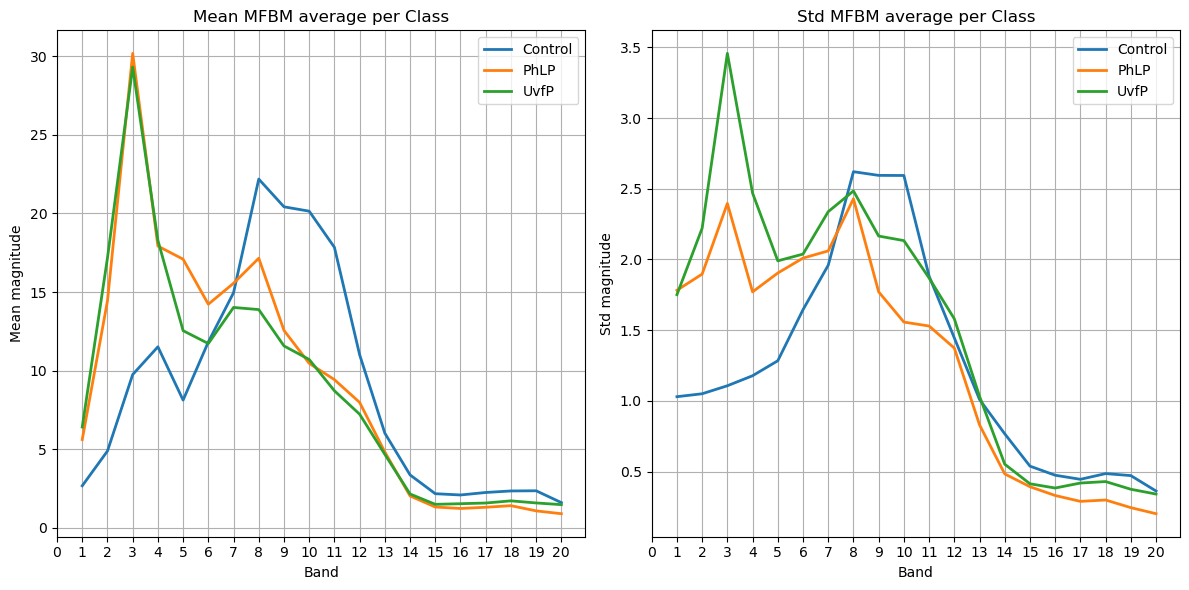

In [3]:
# Calculating band magnitude mean and std dev and adding to dataframe
# These are the features used in the Article

mean_list = []
std_list = []

for mfbm in df['MFBM']:

    # mfbm shape: (n_filters, n_frames)

    mean_bands = np.mean(mfbm, axis=1)  # (20,)
    std_bands = np.std(mfbm, axis=1)    # (20,)

    mean_list.append(mean_bands)
    std_list.append(std_bands)

df['mean_MFBM'] = mean_list
df['std_MFBM'] = std_list


# The Article joined the edema and nodules classes into one, PhLP
# Merging edema and nodules into 'PhLP' class
df.loc[df['group'].isin(['edema', 'nodulo']), 'group'] = 'PhLP'
df.loc[df['group'].isin(['UVFP']), 'group'] = 'UvfP'
df.loc[df['group'].isin(['control']), 'group'] = 'Control'
#df.loc[df['class'] == 3, 'class'] = 1



# Recalculate class codes from scratch after merge
df['class'] = pd.Categorical(df['group']).codes


# Plotting mean and std magintudes per band, per class
plot_meldefined_magnitudes_per_class(
    df,
    save_path = "../results/figures/02mel_bands_per_class.png"
)


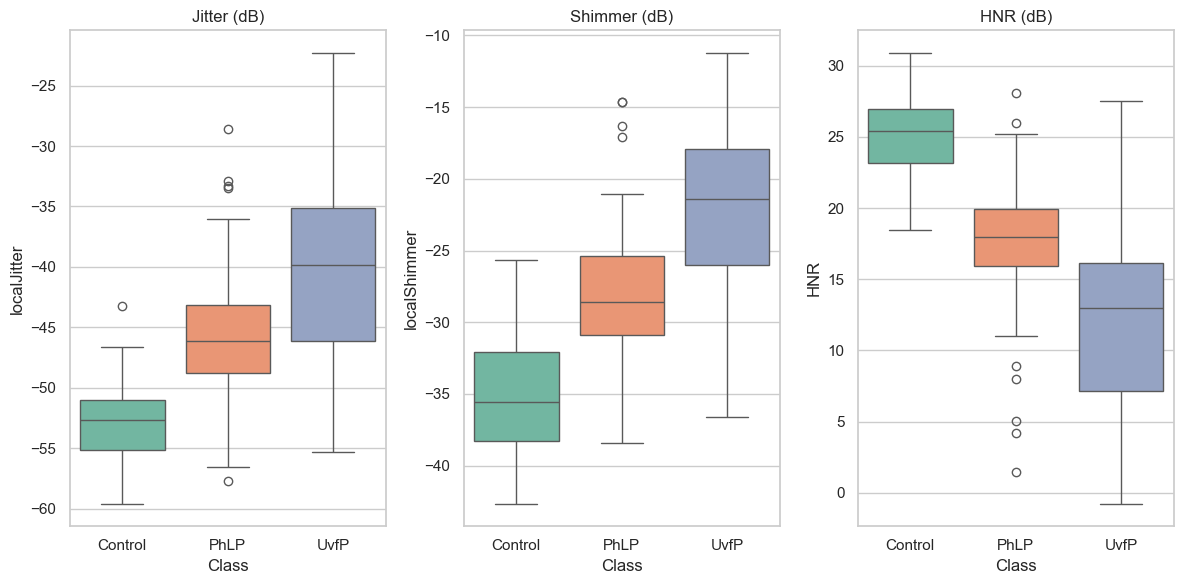

In [4]:
# Show acoustic features per class boxplots
# Jitter and shimmer were converted to dB
# for better visualization

features = [
    ("localJitter", "Jitter (dB)"),
    ("localShimmer", "Shimmer (dB)"),
    ("HNR", "HNR (dB)")
]

plot_acoustic_features(df,
                       features,
                       save_path = "../results/figures/03acoustic_features_per_class.png"
                      )

In [5]:
# ------------------------------------------------------------------
# Experiment grid
# ------------------------------------------------------------------

# Feature sets to evaluate — each will be tested on every task
feature_sets = ["acoustic", "spectral", "all"]

# Classification tasks — each entry maps a task name to the two groups
# involved. None means all classes are used (3-class classification).
tasks = {
    "Control_vs_PhLP": ["Control", "PhLP"],
    "Control_vs_UVFP": ["Control", "UvfP"],
    "PhLP_vs_UVFP":    ["PhLP", "UvfP"],
    "All_classes":     None                 # all three classes
}

# ------------------------------------------------------------------
# Run all experiments
# ------------------------------------------------------------------
results = []

for task_name, groups in tasks.items():

    # Filter dataset to the relevant classes for this task.
    # For the 3-class task, the full dataset is used as-is.
    if groups is None:
        df_task = df.copy()
    else:
        df_task = df[df["group"].isin(groups)].copy()

    # Encode group labels as integer class codes.
    # pd.Categorical preserves a consistent mapping within each task.
    df_task["class"] = pd.Categorical(df_task["group"]).codes

    X = build_X(df_task)       # feature matrix — shape (n_samples, 27)
    y = df_task["class"].values

    # Run cross-validation for each feature set
    for feat in feature_sets:

        metrics = run_cv_experiment(
            X, y,
            feature_set=feat,
            print_report=True
        )

        # Store results alongside task and feature set identifiers
        results.append({
            "task":     task_name,
            "features": feat,
            **metrics
        })

# ------------------------------------------------------------------
# Collect all results into a single DataFrame for analysis and export
# ------------------------------------------------------------------
results_df = pd.DataFrame(results)

Accuracy : 0.8534565217391304
Std Acc  : 0.010275482409715023
Precision: 0.8038807007867341
Recall   : 0.8273888888865905
F1       : 0.8153444726260054
AUC      : 0.9048249007936509

Confusion Matrix (average over iterations)
 [[29.786  6.214]
 [ 7.268 48.732]]

Normalised Confusion Matrix (average over iterations)
 [[0.82738889 0.17261111]
 [0.12978571 0.87021429]]

Accuracy : 0.8646086956521739
Std Acc  : 0.022836602132879247
Precision: 0.8186243924254851
Recall   : 0.8409444444421086
F1       : 0.8291003731697365
AUC      : 0.929048611111111

Confusion Matrix (average over iterations)
 [[30.274  5.726]
 [ 6.73  49.27 ]]

Normalised Confusion Matrix (average over iterations)
 [[0.84094444 0.15905556]
 [0.12017857 0.87982143]]

Accuracy : 0.9448369565217393
Std Acc  : 0.010613143891016358
Precision: 0.9156842122351548
Recall   : 0.9461666666640384
F1       : 0.9305412843820461
AUC      : 0.9644260912698412

Confusion Matrix (average over iterations)
 [[34.062  1.938]
 [ 3.137 52.863]]

In [6]:
# Show results
print(results_df)

# Export results
results_df.to_csv("../results/metrics/summary.csv", sep=";", index=False)


               task  features  accuracy_mean  accuracy_std  precision  \
0   Control_vs_PhLP  acoustic       0.853457      0.010275   0.803881   
1   Control_vs_PhLP  spectral       0.864609      0.022837   0.818624   
2   Control_vs_PhLP       all       0.944837      0.010613   0.915684   
3   Control_vs_UVFP  acoustic       0.907053      0.008533   0.828347   
4   Control_vs_UVFP  spectral       0.864116      0.018434   0.814725   
5   Control_vs_UVFP       all       0.931695      0.005687   0.854891   
6      PhLP_vs_UVFP  acoustic       0.694252      0.013035   0.664506   
7      PhLP_vs_UVFP  spectral       0.678530      0.024208   0.647323   
8      PhLP_vs_UVFP       all       0.728348      0.016965   0.706780   
9       All_classes  acoustic       0.676331      0.011157   0.805766   
10      All_classes  spectral       0.670139      0.021991   0.836707   
11      All_classes       all       0.746682      0.014982   0.894180   

      recall        f1       auc  \
0   0.827389  

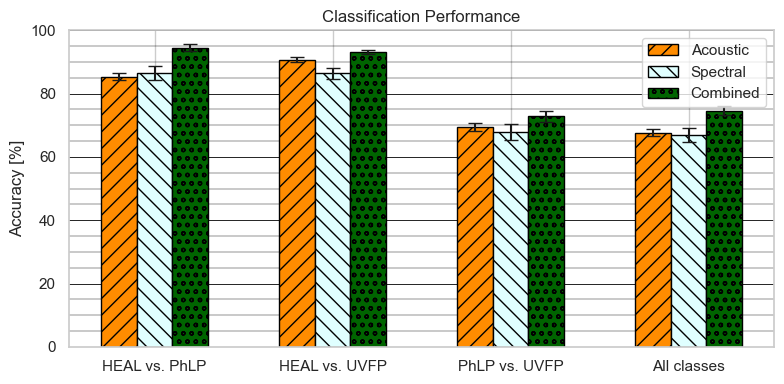

In [7]:
# Plot accuracies bar graph
extra_plot_results_bar(results_df, "../results/figures/04accuracies_bar.png")

In [8]:
# Make, show and save Accuracies Table

table1 = extra_build_table_accuracies(results_df)

table1.to_csv("../results/metrics/accuracies.csv", index=False, sep=";")

print(table1)

  Classification   HE vs. PhLP   HE vs. UVFP PhLP vs. UVFP       3-Class  \
0       Acoustic  85.35 ± 1.03  90.71 ± 0.85  69.43 ± 1.30  67.63 ± 1.12   
1       Spectral  86.46 ± 2.28  86.41 ± 1.84  67.85 ± 2.42  67.01 ± 2.20   
2       Combined  94.48 ± 1.06  93.17 ± 0.57  72.83 ± 1.70  74.67 ± 1.50   

  HE vs. All (*) PhLP vs. All (*) UVFP vs. All (*)  
0   88.36 ± 0.64     70.32 ± 1.13     76.59 ± 0.94  
1   88.02 ± 1.09     72.81 ± 2.11     73.20 ± 2.04  
2   92.91 ± 0.67     77.56 ± 1.58     78.86 ± 1.36  


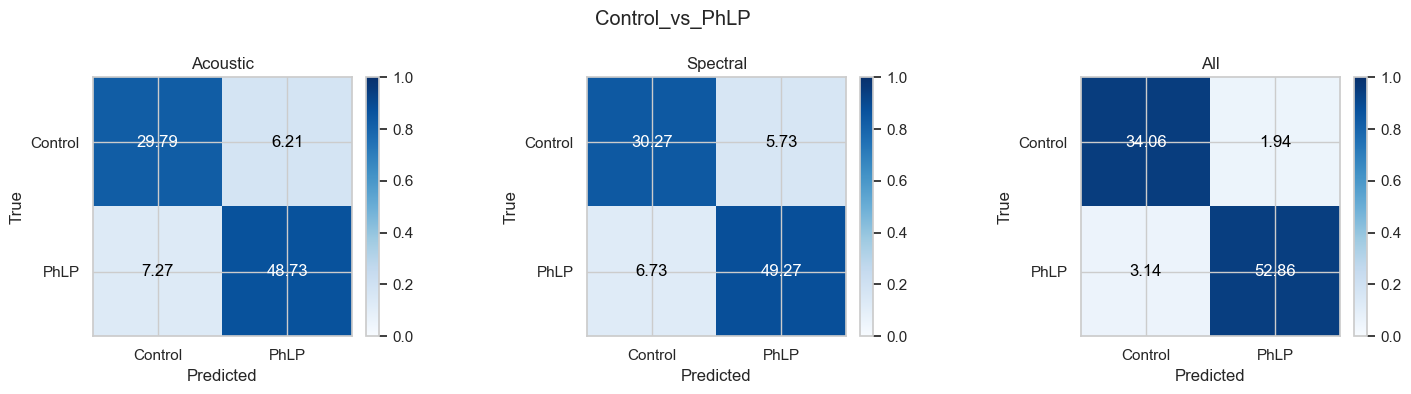

In [9]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="Control_vs_PhLP",
    class_names=["Control", "PhLP"],
    save_path="../results/figures/05_ConfMatr_Control_vs_PhLP"
)

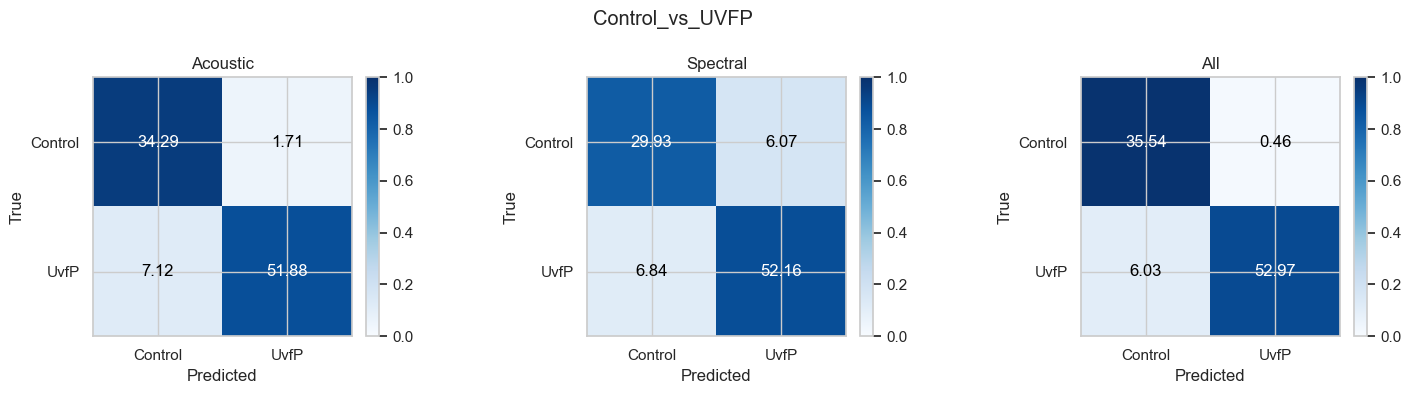

In [10]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="Control_vs_UVFP",
    class_names=["Control", "UvfP"]
)


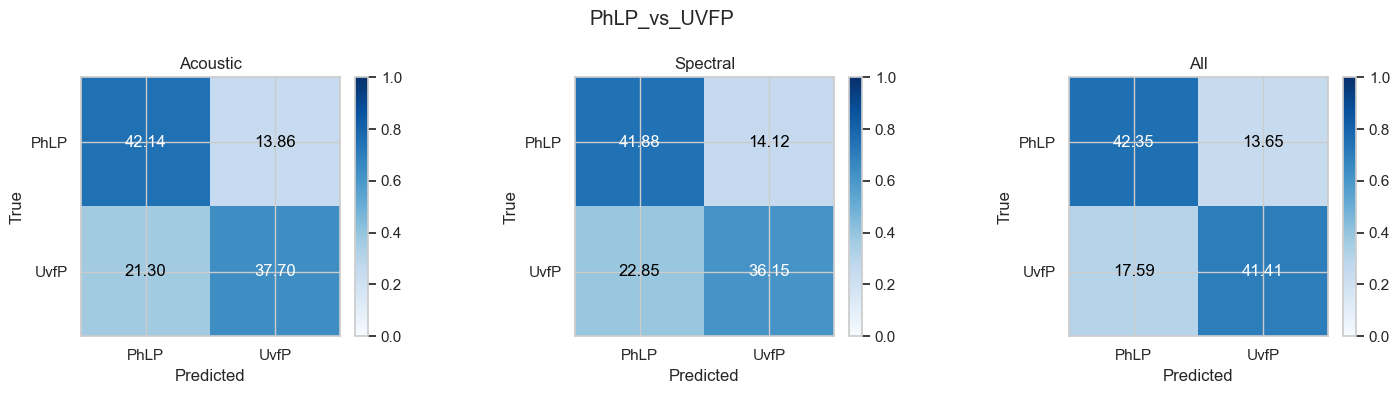

In [11]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="PhLP_vs_UVFP",
    class_names=["PhLP", "UvfP"]
)

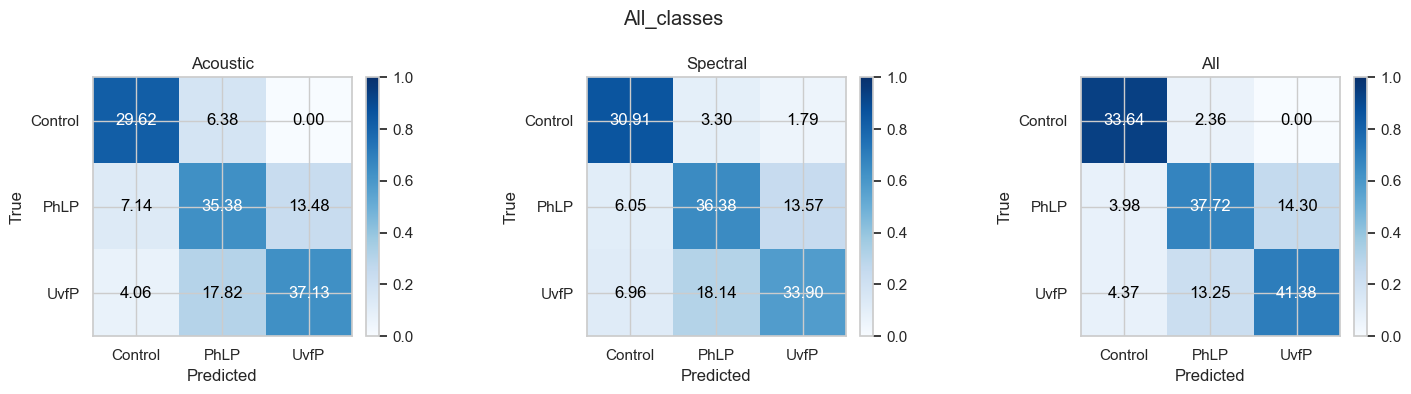

In [12]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="All_classes",
    class_names=["Control", "PhLP", "UvfP"]
)